In [22]:
import nltk
import string
import gensim
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import seaborn as sns
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from nltk.stem import PorterStemmer
import lime
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import permutation_importance

In [23]:
import pandas as pd

# Load the dataset
data_path = r"C:\Users\User\Documents\GIT Main\AISC-T3-Grp1\NLP\Assignment 2\Sentiment_Data.csv"
df = pd.read_csv(data_path)

# Display basic information
df.head()


In [24]:
df.shape

(451332, 2)

In [25]:
df.describe()

,Tweet,Sentiment
count,451331,451332
unique,451279,5
top,#NAME?,Strong_Pos
freq,5,233700


In [26]:
df

,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos
...,...,...
451327,Gaza; Peace n' Freedom - Viva Palestina convoy...,Strong_Pos
451328,Face of Defense: Soldier Finds Freedom in U.S....,Strong_Pos
451329,Face of Defense: Soldier Finds Freedom in U.S....,Strong_Pos
451330,"Gaza; Peace n' Freedom - ""Israel stops aid con...",Strong_Pos


In [27]:
df['Sentiment'].unique()

array(['Mild_Pos', 'Strong_Pos', 'Neutral', 'Strong_Neg', 'Mild_Neg'],
      dtype=object)

In [28]:
def bar_plot(data, label_map=None):
    # Count occurrences of each label
    class_counts = pd.Series(data).value_counts()

    # Plot bar chart
    class_counts.plot(kind="bar", edgecolor="black", figsize=(8, 6))

    # Add values on top of each bar
    for i, v in enumerate(class_counts):
        plt.text(i, v + 0.2, str(v), ha="center", fontsize=12)

    # Customize plot
    plt.xlabel("Sentiment Labels")
    plt.ylabel("Frequency")
    plt.title("Sentiment Distribution in y_train")
    
    # If label_map is provided, replace numeric labels with customer labels
    if label_map is not None:
        # Use the label_map to replace numeric labels
        plt.xticks(range(len(class_counts)), [label_map.get(i) for i in class_counts.index], rotation=0)
    else:
        # If no label_map, show numeric labels
        plt.xticks(range(len(class_counts)), class_counts.index, rotation=0)

    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show the plot
    plt.show()

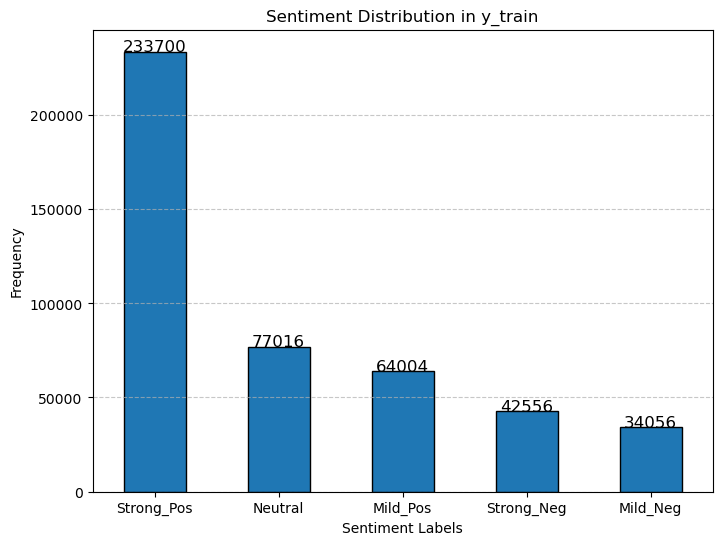

In [29]:
bar_plot(df['Sentiment'])

In [30]:
# 'Negative' -> 0, 'Neutral' -> 1, 'Positive' -> 2
label_map = {'Strong_Pos': 0, 'Mild_Pos' : 1,'Neutral': 2, 'Strong_Neg': 3, 'Mild_Neg': 4}
reverse_label_map = {0: 'Strong_Pos', 1: 'Mild_Pos', 2: "Neutral", 3: 'Strong_Neg', 4: 'Mild_Neg'}

SVM Model using word2vec (CBOW or Skipgram and any vector size from 64 to 300)

In [31]:
# Count the number of samples per class
class_counts = df['Sentiment'].value_counts()
print("\nBefore undersampling:\n", class_counts)

# Define the number of samples to take for each class
sample_sizes = {
    'Strong_Pos': 6000,
    'Mild_Pos': 6000,
    'Neutral': 6000,  # Adjust the sample size for Negative
    'Strong_Neg': 6000,   # Adjust the sample size for Neutral
    'Mild_Neg': 6000   # Adjust the sample size for Positive
}

# Perform undersampling without replacement
df_under = pd.concat([
    df[df['Sentiment'] == label].sample(n=min(sample_sizes[label], len(df[df['Sentiment'] == label])), 
                                        random_state=42, 
                                        replace=False)
    for label in sample_sizes.keys()
])

# Print class distribution after undersampling
print("\nAfter undersampling:\n", df_under['Sentiment'].value_counts())


Before undersampling:
 Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64

After undersampling:
 Sentiment
Strong_Pos    6000
Mild_Pos      6000
Neutral       6000
Strong_Neg    6000
Mild_Neg      6000
Name: count, dtype: int64


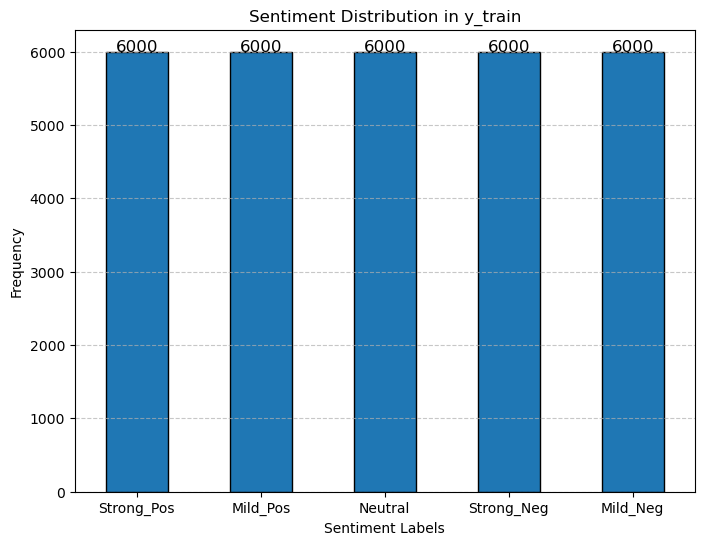

In [32]:
bar_plot(df_under['Sentiment'])

tokenization

In [33]:
df_under['Sentiment'] = df_under['Sentiment'].map(label_map)

In [34]:
df_under['Sentiment']

406658    0
90803     0
75490     0
431292    0
150871    0
         ..
285982    4
409454    4
397305    4
195898    4
101315    4
Name: Sentiment, Length: 30000, dtype: int64

In [35]:
# Function to get the tweet vector by averaging word vectors
def get_tweet_vector(tweet_tokens, model):
    vector = np.zeros(model.vector_size)  # Initialize a zero vector
    valid_words = 0
    for word in tweet_tokens:
        if word in model.wv:
            vector += model.wv[word]  # Add the word vector to the total sum
            valid_words += 1
    if valid_words > 0:
        vector /= valid_words  # Return the average word vector for the tweet
    return vector

Lime

In [36]:
def lime_explanation_single_record(model, X_train_vectors, X_test_vector, reverse_label_map, word2vec_model):
    """
    Generates a LIME explanation for a single instance using an SVM model and precomputed Word2Vec vectors.

    Parameters:
    - model: Trained SVM classifier with probability=True
    - X_train_vectors: Numpy array of precomputed Word2Vec vectors (training set)
    - X_test_vector: A single test instance (Word2Vec vector)
    - reverse_label_map: Dictionary mapping class indices to labels
    - word2vec_model: Trained Word2Vec model to get feature (word) names
    """

    # Extract class names from reverse_label_map
    class_names = [reverse_label_map[i] for i in range(len(reverse_label_map))]

    # Get feature (word) names from the Word2Vec vocabulary
    feature_names = list(word2vec_model.wv.index_to_key)[:X_train_vectors.shape[1]]  # Use only available features

    # Initialize LIME Tabular Explainer
    explainer = LimeTabularExplainer(
        training_data=X_train_vectors,  
        feature_names=feature_names,  # Use actual words as feature names
        class_names=class_names,  
        mode="classification"
    )

    # Reshape the test vector to match LIME input format
    instance = X_test_vector.reshape(1, -1)

    # Define prediction function for LIME
    predict_fn = lambda x: model.predict_proba(x)

    # Generate LIME explanation
    exp = explainer.explain_instance(instance[0], predict_fn, num_features=10, top_labels=5)

    # Show explanation
    exp.show_in_notebook()

    return exp


# SVM

In [ ]:
# Apply preprocessing to the text data
df_under['stem_tokens'] = df_under['Tweet'].apply(preprocess_stopwords_stemming)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df_under['stem_tokens'], df_under['Sentiment'], test_size=0.2, random_state=42)
print("\nTraining and Testing Split:")
print(f"\nTraining Data:\n shape: {x_train.shape} \n {x_train},\n\n Test Data:\n shape: {x_test.shape} \n {x_test}")
print(f"\nTraining Target Data:\n shape: {y_train.shape} \n {y_train},\n\n Test Target Data:\n shape: {y_test.shape} \n {y_test}")

In [ ]:
# Train the Word2Vec model (Skipgram model with vector size 100) on the whole df_under stem_tokens
word2vec_model = gensim.models.Word2Vec(sentences=df_under['stem_tokens'], vector_size=100, window=5, min_count=1, sg=1)

In [ ]:
# Generate vectors for the training set using the trained Word2Vec model
x_train_vectors = [get_tweet_vector(tweet, word2vec_model) for tweet in x_train]

# Generate vectors for the test set using the already trained Word2Vec model
x_test_vectors = [get_tweet_vector(tweet, word2vec_model) for tweet in x_test]

In [ ]:
# Prepare data for SVM model
x_train_array = np.array(x_train_vectors)  # Features: Tweet vectors (Training data)
x_test_array = np.array(x_test_vectors)  # Features: Tweet vectors (Test data)
y_train_array = np.array(y_train)  # Labels: Sentiments (Training data)
y_test_array = np.array(y_test)  # Labels: Sentiments (Test data)

print('x_train_array shape: ', x_train_array.shape)
print('x_test_array shape: ', x_test_array.shape)
print('y_train_array shape: ', y_train_array.shape)
print('y_test_array shape: ', y_test_array.shape)

In [ ]:
# Initialize the SVM model with a linear kernel
svm_classifier = SVC(kernel='linear', probability=True)

# Measure training time
start_time = time.time()

# Train the SVM model
svm_classifier.fit(x_train_array, y_train_array)

# Calculate training time
training_time = time.time() - start_time
print(f"Training time: {training_time:.2f} seconds")

# Predictions
y_train_pred = svm_classifier.predict(x_train_array)
y_test_pred = svm_classifier.predict(x_test_array)

# Print Classification Report
print("\nClassification Report (Train Set):")
print(classification_report(y_train_array, y_train_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test_array, y_test_pred))

# Compute Confusion Matrices
conf_matrix_train = confusion_matrix(y_train_array, y_train_pred)
conf_matrix_test = confusion_matrix(y_test_array, y_test_pred)

# Class labels mapping
classes = [reverse_label_map[i] for i in range(len(label_map))]

# Plot Confusion Matrix for Train & Test
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train Set Confusion Matrix
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Confusion Matrix - Train Set")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Test Set Confusion Matrix
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Confusion Matrix - Test Set")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.show()

# Binarize labels for ROC curve
y_train_bin = label_binarize(y_train_array, classes=[0, 1, 2, 3, 4])
y_test_bin = label_binarize(y_test_array, classes=[0, 1, 2, 3, 4])

# Compute ROC Curve and AUC for Train and Test sets separately
plt.figure(figsize=(12, 6))

# Plot ROC for Train Set
plt.subplot(1, 2, 1)
plt.title('ROC Curve - Train Set')
for i in range(len(classes)):
    fpr_train, tpr_train, _ = roc_curve(y_train_bin[:, i], svm_classifier.predict_proba(x_train_array)[:, i])
    roc_auc_train = auc(fpr_train, tpr_train)
    
    plt.plot(fpr_train, tpr_train, label=f'{classes[i]} (AUC = {roc_auc_train:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

# Plot ROC for Test Set
plt.subplot(1, 2, 2)
plt.title('ROC Curve - Test Set')
for i in range(len(classes)):
    fpr_test, tpr_test, _ = roc_curve(y_test_bin[:, i], svm_classifier.predict_proba(x_test_array)[:, i])
    roc_auc_test = auc(fpr_test, tpr_test)
    
    plt.plot(fpr_test, tpr_test, label=f'{classes[i]} (AUC = {roc_auc_test:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


# Get the list of words in your model (for example, the vocabulary)
words = list(word2vec_model.wv.index_to_key)

# Now we look at the coefficients from the SVM model
coef = svm_classifier.coef_.flatten()  # Coefficients from the SVM model

# Get top N features (words) that have the highest coefficients (importance)
top_indices = np.argsort(coef)[-10:][::-1]  # Indices of the highest coefficients

# Map these indices back to the words in your word2vec model
top_words = [words[i] for i in top_indices]

# Print top 10 words with the highest coefficients
print("Top 10 Words with the Highest Coefficients:")
for word in top_words:
    print(f"{word}: {coef[words.index(word)]:.4f}")

In [ ]:
lime_explanation_single_record(svm_classifier, x_train_array, x_test_array[0], reverse_label_map, word2vec_model)

model was unable to learn the train data completely. will be doing grid search with hyper parameter to find the best model

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming x_train_array, y_train_array, x_test_array, y_test_array are already prepared

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],  # Regularization parameter
    'kernel': ['linear', 'rbf'],  # Kernel types
    'probability': [True],  # Enable probability estimates for ROC
}

# Initialize the SVM classifier
svm_classifier = SVC()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=svm_classifier, param_grid=param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)

# Measure training time
start_time = time.time()

# Fit the model with GridSearchCV
grid_search.fit(x_train_array, y_train_array)

# Calculate training time
training_time = time.time() - start_time
print(f"Training time: {training_time:.2f} seconds")

# Get the best parameters from GridSearchCV
best_params = grid_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Predictions using the best estimator
svm_best = grid_search.best_estimator_

y_train_pred = svm_best.predict(x_train_array)
y_test_pred = svm_best.predict(x_test_array)

# Print Classification Report
print("\nClassification Report (Train Set):")
print(classification_report(y_train_array, y_train_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test_array, y_test_pred))

# Compute Confusion Matrices
conf_matrix_train = confusion_matrix(y_train_array, y_train_pred)
conf_matrix_test = confusion_matrix(y_test_array, y_test_pred)

# Class labels mapping
classes = [reverse_label_map[i] for i in range(len(label_map))]

# Plot Confusion Matrix for Train & Test
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train Set Confusion Matrix
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Confusion Matrix - Train Set")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Test Set Confusion Matrix
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Confusion Matrix - Test Set")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.show()

# Binarize labels for ROC curve
y_train_bin = LabelBinarizer().fit_transform(y_train_array)
y_test_bin = LabelBinarizer().fit_transform(y_test_array)

# Compute ROC Curve and AUC for Train and Test sets separately
plt.figure(figsize=(12, 6))

# Plot ROC for Train Set
plt.subplot(1, 2, 1)
plt.title('ROC Curve - Train Set')
for i in range(len(classes)):
    fpr_train, tpr_train, _ = roc_curve(y_train_bin[:, i], svm_best.predict_proba(x_train_array)[:, i])
    roc_auc_train = auc(fpr_train, tpr_train)
    plt.plot(fpr_train, tpr_train, label=f'{classes[i]} (AUC = {roc_auc_train:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

# Plot ROC for Test Set
plt.subplot(1, 2, 2)
plt.title('ROC Curve - Test Set')
for i in range(len(classes)):
    fpr_test, tpr_test, _ = roc_curve(y_test_bin[:, i], svm_best.predict_proba(x_test_array)[:, i])
    roc_auc_test = auc(fpr_test, tpr_test)
    plt.plot(fpr_test, tpr_test, label=f'{classes[i]} (AUC = {roc_auc_test:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


In [ ]:
lime_explanation_single_record(svm_best, x_train_array, x_test_array[0], reverse_label_map, word2vec_model)

# Deep Unidirectional RNN Model with an embedding layer to learn embeddings

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout


# Download stopwords
nltk.download("stopwords")

In [ ]:
df

In [ ]:
bar_plot(df['Sentiment'])

In [ ]:
# Count the number of samples per class
class_counts = df['Sentiment'].value_counts()
print("\nBefore undersampling:\n", class_counts)

# Define the number of samples to take for each class
sample_sizes = {
    'Strong_Pos':15000,
    'Mild_Pos':15000,
    'Neutral': 15000,  # Adjust the sample size for Negative
    'Strong_Neg': 15000,   # Adjust the sample size for Neutral
    'Mild_Neg': 15000   # Adjust the sample size for Positive
}

# Perform undersampling without replacement
df_rnn = pd.concat([
    df[df['Sentiment'] == label].sample(n=min(sample_sizes[label], len(df[df['Sentiment'] == label])), 
                                        random_state=42, 
                                        replace=False)
    for label in sample_sizes.keys()
])

# Print class distribution after undersampling
print("\nAfter undersampling:\n", df_rnn['Sentiment'].value_counts())

In [ ]:
# Apply preprocessing
df_rnn["Cleaned_Tweet"] = df_rnn["Tweet"].apply(preprocess_stopwords_stemming)

df_rnn["Sentiment"] = df_rnn["Sentiment"].map(label_map)

# Define input (text) and target (label)
x = df_rnn["Cleaned_Tweet"].values
y = df_rnn["Sentiment"].values

print(x.shape)
print(y.shape)

print(x)
print(y)

In [ ]:
# Tokenization and padding
max_words = 50000  # Vocabulary size
max_len = 50  # Maximum sequence length (increased to 5000)

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(x)
sequences = tokenizer.texts_to_sequences(x)
x_padded = pad_sequences(sequences, maxlen=max_len, padding="post", truncating="post")

In [ ]:
# Split data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x_padded, y, test_size=0.2, random_state=42)

In [ ]:
print(x_train)

In [ ]:
# Define the model
model = Sequential()

# Embedding Layer: Learns a representation for each word in the input text
model.add(Embedding(input_dim=max_words, output_dim=100, input_length=max_len))

# Deep Unidirectional RNN layers
model.add(SimpleRNN(64, return_sequences=True))  # First RNN layer
model.add(Dropout(0.5))  # Dropout to prevent overfitting

model.add(SimpleRNN(64))  # Second RNN layer
model.add(Dropout(0.5))  # Dropout to prevent overfitting

# Output Layer: 3 classes for classification
model.add(Dense(5, activation='softmax'))  # 5 classes for 5 possible labels (0, 1, 2, 3, 4)

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
model.summary()

In [ ]:
start_time = time.time()
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))
# Calculate training time
training_time = time.time() - start_time
print(f"Training time: {training_time:.2f} seconds")

In [35]:
# Function to plot confusion matrix with reverse label map
def plot_confusion_matrix(y_true, y_pred, title, reverse_label_map):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    
    # Extracting the class labels from the reverse_label_map dynamically
    class_labels = [reverse_label_map[i] for i in sorted(reverse_label_map.keys())]
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

In [ ]:
print(y_train.shape)

In [ ]:
import numpy as np
from lime.lime_text import LimeTextExplainer

def lime_explanation_rnn(model, sample_text_sequence, reverse_label_map, max_len):
    """
    Generates a LIME explanation for a single RNN input.

    Parameters:
    - model: Trained RNN model with an embedding layer
    - sample_text_sequence: A single processed test instance (already tokenized & padded)
    - reverse_label_map: Dictionary mapping class indices to labels
    - max_len: Maximum sequence length (same as used in Embedding layer)
    """

    # Define class names from reverse_label_map
    class_names = [reverse_label_map[i] for i in range(len(reverse_label_map))]

    # Initialize LIME explainer
    explainer = LimeTextExplainer(class_names=class_names)

    # Define the prediction function for LIME
    def predict_fn(text_instances):
        """
        Converts LIME text instances (words) into padded sequences & predicts probabilities.
        """
        # Convert words into numerical sequences
        sequences = [np.array(list(map(int, text.split()))) for text in text_instances]

        # Pad sequences to max_len
        sequences_padded = np.array([np.pad(seq, (0, max_len - len(seq)), 'constant') for seq in sequences])

        # Get model predictions
        return model.predict(sequences_padded)

    # Generate LIME explanation
    exp = explainer.explain_instance(
        " ".join(map(str, sample_text_sequence)),  # Convert array to space-separated string
        predict_fn,
        num_features=10,
        top_labels=5
    )

    # Show explanation
    exp.show_in_notebook()

    return exp

In [ ]:
# For Keras models, use predict() to get probabilities
y_train_pred_probs = model.predict(x_train)
y_test_pred_probs = model.predict(x_test)

# Check shapes of predictions and labels
print(y_train_pred_probs.shape)
print(y_test_pred_probs.shape)
print(y_train.shape)
print(y_test.shape)

# Convert predicted probabilities to class labels (for multi-class classification)
if len(y_train_pred_probs.shape) > 1:
    # For multi-class classification, get the class with highest probability
    y_train_pred_classes = np.argmax(y_train_pred_probs, axis=1)
    y_test_pred_classes = np.argmax(y_test_pred_probs, axis=1)
else:
    # For binary classification (if the model output is a single probability), round it to 0 or 1
    y_train_pred_classes = np.round(y_train_pred_probs).astype(int)
    y_test_pred_classes = np.round(y_test_pred_probs).astype(int)

# Since y_train and y_test are already class labels, no need to apply np.argmax
y_train_true = y_train
y_test_true = y_test

# Calculate accuracy and print reports
train_accuracy = accuracy_score(y_train_true, y_train_pred_classes)
test_accuracy = accuracy_score(y_test_true, y_test_pred_classes)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Extract class labels dynamically (assuming reverse_label_map is defined)
class_labels = [reverse_label_map[i] for i in sorted(reverse_label_map.keys())]

# Print classification report
print("\nClassification Report - Train Data")
print(classification_report(y_train_true, y_train_pred_classes, target_names=class_labels))

print("\nClassification Report - Test Data")
print(classification_report(y_test_true, y_test_pred_classes, target_names=class_labels))

# Plot confusion matrix for train and test data
plot_confusion_matrix(y_train_true, y_train_pred_classes, "Confusion Matrix - Train Data", reverse_label_map)
plot_confusion_matrix(y_test_true, y_test_pred_classes, "Confusion Matrix - Test Data", reverse_label_map)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels for multi-class classification
y_train_bin = label_binarize(y_train_true, classes=[0, 1, 2, 3, 4])  # Adjust based on your classes
y_test_bin = label_binarize(y_test_true, classes=[0, 1, 2, 3, 4])    # Adjust based on your classes

# Initialize dictionaries for ROC curve and AUC calculations
fpr_train = {}
tpr_train = {}
roc_auc_train = {}
fpr_test = {}
tpr_test = {}
roc_auc_test = {}

# Compute ROC curve and AUC for each class (one-vs-rest)
for i in range(y_train_bin.shape[1]):
    fpr_train[i], tpr_train[i], _ = roc_curve(y_train_bin[:, i], y_train_pred_probs[:, i])
    roc_auc_train[i] = auc(fpr_train[i], tpr_train[i])

    fpr_test[i], tpr_test[i], _ = roc_curve(y_test_bin[:, i], y_test_pred_probs[:, i])
    roc_auc_test[i] = auc(fpr_test[i], tpr_test[i])

# Plot ROC curves for Train Data
plt.figure(figsize=(10, 8))
for i in range(y_train_bin.shape[1]):
    plt.plot(fpr_train[i], tpr_train[i], label=f'{reverse_label_map[i]} (AUC = {roc_auc_train[i]:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Labels and title for Train Data
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Train Data')
plt.legend(loc="lower right")
plt.show()

# Plot ROC curves for Test Data
plt.figure(figsize=(10, 8))
for i in range(y_test_bin.shape[1]):
    plt.plot(fpr_test[i], tpr_test[i], label=f'{reverse_label_map[i]} (AUC = {roc_auc_test[i]:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Labels and title for Test Data
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Data')
plt.legend(loc="lower right")
plt.show()


Lime

In [ ]:
lime_explanation_rnn(model, x_test[0], reverse_label_map, 50)

adding rnn layers to improve accuracy and balancing all weights

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dropout, Dense
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights to address class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

# Define the model
model = Sequential()

# Embedding Layer: Learns a representation for each word in the input text
model.add(Embedding(input_dim=max_words, output_dim=100, input_length=max_len))

# First Unidirectional SimpleRNN Layer
model.add(SimpleRNN(128, return_sequences=True))  # Return sequences for the next RNN layer
model.add(Dropout(0.5))  # Dropout to prevent overfitting

# Second Unidirectional SimpleRNN Layer
model.add(SimpleRNN(128, return_sequences=True))  # Return sequences for the next RNN layer
model.add(Dropout(0.5))  # Dropout to prevent overfitting

# Third Unidirectional SimpleRNN Layer
model.add(SimpleRNN(128))  # No need to return sequences here, as it's the final layer
model.add(Dropout(0.5))  # Dropout to prevent overfitting

# Output Layer: 5 classes for classification
model.add(Dense(5, activation='softmax'))  # 5 classes for 5 possible labels (0, 1, 2, 3, 4)

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
model.summary()

# Train the model with class weights
start_time = time.time()
model.fit(x_train, y_train, epochs=10, batch_size=150, validation_data=(x_test, y_test), class_weight=class_weights)

# Calculate training time
training_time = time.time() - start_time
print(f"Training time: {training_time:.2f} seconds")


In [ ]:
# For Keras models, use predict() to get probabilities
y_train_pred_probs = model.predict(x_train)
y_test_pred_probs = model.predict(x_test)

# Check shapes of predictions and labels
print(y_train_pred_probs.shape)
print(y_test_pred_probs.shape)
print(y_train.shape)
print(y_test.shape)

# Convert predicted probabilities to class labels (for multi-class classification)
if len(y_train_pred_probs.shape) > 1:
    # For multi-class classification, get the class with highest probability
    y_train_pred_classes = np.argmax(y_train_pred_probs, axis=1)
    y_test_pred_classes = np.argmax(y_test_pred_probs, axis=1)
else:
    # For binary classification (if the model output is a single probability), round it to 0 or 1
    y_train_pred_classes = np.round(y_train_pred_probs).astype(int)
    y_test_pred_classes = np.round(y_test_pred_probs).astype(int)

# Since y_train and y_test are already class labels, no need to apply np.argmax
y_train_true = y_train
y_test_true = y_test

# Calculate accuracy and print reports
train_accuracy = accuracy_score(y_train_true, y_train_pred_classes)
test_accuracy = accuracy_score(y_test_true, y_test_pred_classes)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Extract class labels dynamically (assuming reverse_label_map is defined)
class_labels = [reverse_label_map[i] for i in sorted(reverse_label_map.keys())]

# Print classification report
print("\nClassification Report - Train Data")
print(classification_report(y_train_true, y_train_pred_classes, target_names=class_labels))

print("\nClassification Report - Test Data")
print(classification_report(y_test_true, y_test_pred_classes, target_names=class_labels))

# Plot confusion matrix for train and test data
plot_confusion_matrix(y_train_true, y_train_pred_classes, "Confusion Matrix - Train Data", reverse_label_map)
plot_confusion_matrix(y_test_true, y_test_pred_classes, "Confusion Matrix - Test Data", reverse_label_map)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels for multi-class classification
y_train_bin = label_binarize(y_train_true, classes=[0, 1, 2, 3, 4])  # Adjust based on your classes
y_test_bin = label_binarize(y_test_true, classes=[0, 1, 2, 3, 4])    # Adjust based on your classes

# Initialize dictionaries for ROC curve and AUC calculations
fpr_train = {}
tpr_train = {}
roc_auc_train = {}
fpr_test = {}
tpr_test = {}
roc_auc_test = {}

# Compute ROC curve and AUC for each class (one-vs-rest)
for i in range(y_train_bin.shape[1]):
    fpr_train[i], tpr_train[i], _ = roc_curve(y_train_bin[:, i], y_train_pred_probs[:, i])
    roc_auc_train[i] = auc(fpr_train[i], tpr_train[i])

    fpr_test[i], tpr_test[i], _ = roc_curve(y_test_bin[:, i], y_test_pred_probs[:, i])
    roc_auc_test[i] = auc(fpr_test[i], tpr_test[i])

# Plot ROC curves for Train Data
plt.figure(figsize=(10, 8))
for i in range(y_train_bin.shape[1]):
    plt.plot(fpr_train[i], tpr_train[i], label=f'{reverse_label_map[i]} (AUC = {roc_auc_train[i]:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Labels and title for Train Data
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Train Data')
plt.legend(loc="lower right")
plt.show()

# Plot ROC curves for Test Data
plt.figure(figsize=(10, 8))
for i in range(y_test_bin.shape[1]):
    plt.plot(fpr_test[i], tpr_test[i], label=f'{reverse_label_map[i]} (AUC = {roc_auc_test[i]:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Labels and title for Test Data
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Data')
plt.legend(loc="lower right")
plt.show()

we can train the model with data that has test data characterists or increase the rnn layers or do hyerparameter tunning to increase the accuary

In [ ]:
print(x_test[0])

In [ ]:
print(reverse_label_map[y_test[0]])

Lime

In [ ]:
lime_explanation_rnn(model, x_test[0], reverse_label_map, 50)

# Single Layer Bidirectional GRU Model using word2vec (CBOW or Skipgram and any vector size from 64 to 300)

In [33]:
import numpy as np
import nltk
from nltk.stem import PorterStemmer
from keras.models import Sequential
from keras.layers import GRU, Bidirectional, Dense, Dropout
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [17]:
df

,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos
...,...,...
451327,Gaza; Peace n' Freedom - Viva Palestina convoy...,Strong_Pos
451328,Face of Defense: Soldier Finds Freedom in U.S....,Strong_Pos
451329,Face of Defense: Soldier Finds Freedom in U.S....,Strong_Pos
451330,"Gaza; Peace n' Freedom - ""Israel stops aid con...",Strong_Pos


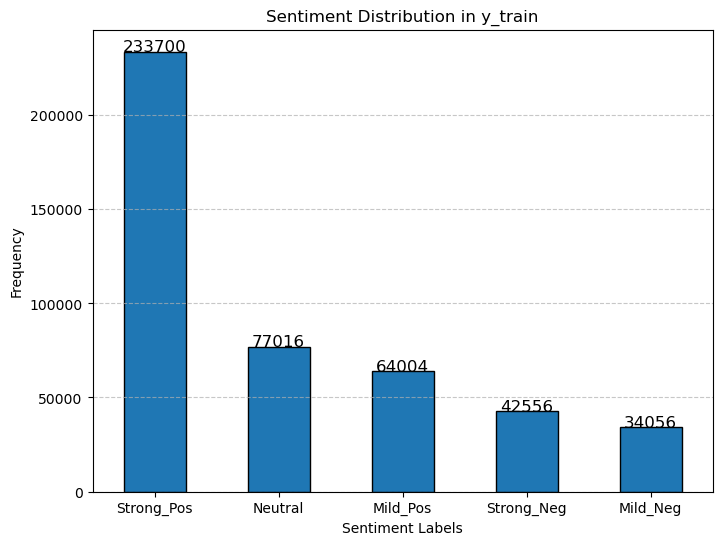

In [22]:
bar_plot(df['Sentiment'])

In [18]:
# Count the number of samples per class
class_counts = df['Sentiment'].value_counts()
print("\nBefore undersampling:\n", class_counts)

# Define the number of samples to take for each class
sample_sizes = {
    'Strong_Pos': 30000,
    'Mild_Pos': 30000,
    'Neutral': 30000,  # Adjust the sample size for Negative
    'Strong_Neg': 30000,   # Adjust the sample size for Neutral
    'Mild_Neg': 30000   # Adjust the sample size for Positive
}

# Perform undersampling without replacement
df_gru = pd.concat([
    df[df['Sentiment'] == label].sample(n=min(sample_sizes[label], len(df[df['Sentiment'] == label])), 
                                        random_state=42, 
                                        replace=False)
    for label in sample_sizes.keys()
])

# Print class distribution after undersampling
print("\nAfter undersampling:\n", df_gru['Sentiment'].value_counts())


Before undersampling:
 Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64

After undersampling:
 Sentiment
Strong_Pos    30000
Mild_Pos      30000
Neutral       30000
Strong_Neg    30000
Mild_Neg      30000
Name: count, dtype: int64


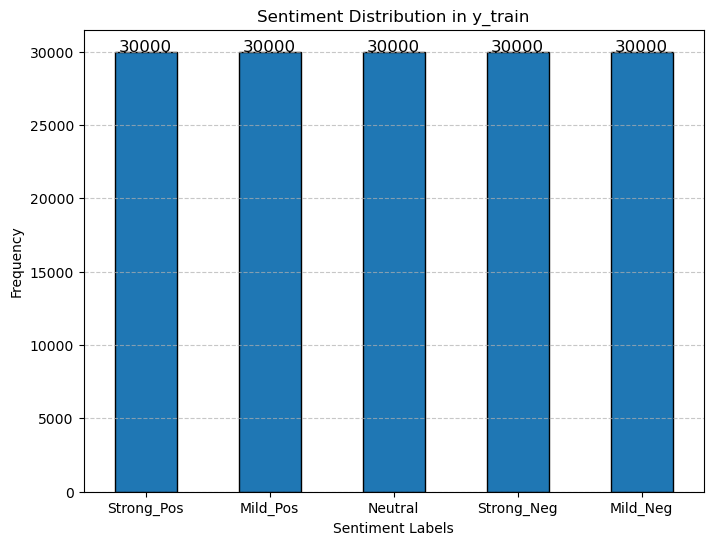

In [19]:
bar_plot(df_gru['Sentiment'])

In [20]:
df_gru['Sentiment'] = df_gru['Sentiment'].map(label_map)
y = df_gru['Sentiment']

In [21]:
# Apply preprocessing to the text data
df_gru['stem_tokens'] = df_gru['Tweet'].apply(preprocess_stopwords_stemming)

In [23]:
# Train a Word2Vec model (CBOW model)
word2vec_model = Word2Vec(sentences = df_gru['stem_tokens'], vector_size=200, window=5, min_count=1, sg=0)

Implement word2vector for the tweet data

In [26]:
import numpy as np

# Function to convert a tweet (list of words) into a vector
def get_tweet_vector(words, model, vector_size=200):
    vec = np.zeros(vector_size)
    count = 0
    for word in words:  # No need to split, 'words' is already a list
        if word in model.wv:
            vec += model.wv[word]
            count += 1
    if count > 0:
        vec /= count  # Average word vectors
    return vec

In [27]:
x = np.array([get_tweet_vector(tweet, word2vec_model) for tweet in df_gru['stem_tokens']])

In [28]:
# Split into train and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [84]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

def explain_single_instance_with_lime(model, x_test_instance, num_features=10):
    """
    Explains a single instance from x_test using LIME.

    Parameters:
    - model: The trained Bidirectional GRU model
    - x_test_instance: A single test instance (e.g., x_test[0]) to explain
    - num_features: Number of features to display in the explanation

    Returns:
    - Explanation object containing the explanation of the prediction
    """
    
    # Flatten the instance for LIME
    x_test_instance_flattened = x_test_instance.reshape(1, -1)  # Flatten the instance (timesteps * features)

    # Function to predict class probabilities (same as model.predict)
    def predict_fn(x):
        # Reshape the input back to (batch_size, timesteps, features) for the GRU model
        x_reshaped = x.reshape(x.shape[0], x_test_instance.shape[0], x_test_instance.shape[1])
        return model.predict(x_reshaped)

    # Initialize LIME's Tabular Explainer
    explainer = LimeTabularExplainer(
        training_data=x_train.reshape(x_train.shape[0], -1),  # Flatten training data to match model input shape
        mode="classification",  # Classification task
        class_names=list(reverse_label_map.values()),  # Using reverse_label_map for class names
        feature_names=[f"Feature {i}" for i in range(x_test_instance_flattened.shape[1])],  # Flattened feature names
        discretize_continuous=True  # Handle continuous features
    )

    # Explain the instance
    explanation = explainer.explain_instance(
        x_test_instance_flattened[0],  # Flattened instance
        predict_fn,  # The prediction function for the model
        num_features=num_features,  # Limit to the top N features
        top_labels=5
    )

    # Display the explanation (in notebook, or in a web-based view)
    explanation.show_in_notebook()

    return explanation